## Data pre-proccesing and Analysis

In [39]:
import pandas as pd
from sklearn.preprocessing import RobustScaler, PowerTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
import plotnine as p9
import matplotlib.pyplot as plt
df = pd.read_csv('dataset_clean_tidy_filled.csv')

### Feature Selection: Which Columns Should We Discard?

Before proceeding with the preprocessing and model training, we must carefully filter our dataset and remove specific columns from our feature matrix ($X$).

**1. The Target Variable (`hospdead`)**
Because we are using a supervised learning approach, `hospdead` is our primary target variable. While it is obviously essential for training the algorithm, it must be separated from the predictors into its own label vector ($y$). Keeping it inside the feature matrix would result in the model using the final answer to predict the answer itself.

**2. Preventing Data Leakage (`dnr`)**
As documented in the dataset's README, the `dnr` (Do Not Resuscitate) status is often assigned *during* the hospital stay, typically as a direct response to a worsening clinical condition. Because it is correlated with the outcome by design, including it would introduce severe data leakage effectively allowing the model to peek into the future. Thus, we exclude this column entirely from our analysis.

**3. Why dropping `hday`?**
The hday feature is excluded from the predictive model to prevent significant data leakage and selection bias. As hday represents the duration of the hospital stay at the time of study entry (or discharge), it is fundamentally a temporal outcome variable rather than an independent clinical measurement available at the time of admission.Consequently, hday is omitted to ensure the model maintains strict adherence to the predictive protocol, grounding its mortality estimations solely on baseline clinical data available at the designated 3-day window.

**3. Dropping Composite Scores to Prevent Multicollinearity (`aps`)**
As indicated in the dataset documentation, the variable `aps` represents an aggregated severity or prognosis score. We have strictly decided to exclude this composite column from our feature matrix for two fundamental machine learning reasons:

* **Severe Multicollinearity:** This prognostic score is mathematically derived directly from the raw physiological data already present in our dataset (e.g., blood pressure, white blood cell count, temperature, age). Keeping both the raw features and the aggregated scores introduces severe multicollinearity, which can artificially inflate feature importance metrics, confuse the algorithm, and reduce the overall interpretability of the model.
* **Algorithmic Autonomy:** The core objective of training an advanced classifier is to allow the algorithm to independently discover complex, non-linear relationships straight from the raw clinical measurements. Feeding the model human-engineered, pre-calculated probability scores is inherently redundant and defeats the purpose of letting the machine learning model identify its own predictive patterns.

In [10]:
df = df.drop(columns=['dnr','aps','hday'])

### Encoding Categorical Variables: The Choice of One-Hot Encoding

In addition to numerical data, our dataset contains string-based categorical variables such as `dzgroup` (disease group), `ca` (cancer status), `race` and `sex`. To process these variables, we will apply a `OneHotEncoder`.

**Why One-Hot Encoding instead of Ordinal Encoding?**
These specific variables are *nominal*, meaning their categories possess no inherent hierarchical or numerical order. If we were to use an `OrdinalEncoder` (which assigns sequential integers like 0, 1, 2 to different categories), the machine learning model could be easily confused. The algorithm might misinterpret these assigned numbers as having a mathematical magnitude or sequential correlation (e.g., falsely assuming that category 2 is mathematically "greater" than category 1). 

By using `OneHotEncoder`, we transform each category into its own independent binary column (0 or 1). This ensures that the model treats every disease, cancer status, and ethnicity as purely independent, preventing the algorithm from inferring mathematical correlations that do not exist in reality.

### Feature Scaling Strategy for Quantitative Data

For our quantitative data, we cannot apply a "one-size-fits-all" scaling method. Biological and clinical metrics behave differently, and forcing them into a single transformation would distort their intrinsic medical meaning. Therefore, we divided our numerical features into three specific preprocessing groups:

**1. Data Left Unchanged (Passthrough)**
Certain numerical values must remain untouched to preserve their logical and clinical integrity:
* **Binary Variables (`diabetes`, `dementia`):** These are already naturally encoded as `0.0` or `1.0`, acting as absolute boolean switches (absence/presence). Scaling them would make no mathematical sense.
* **Ordinal Variables (`scoma`, `adlsc`, `num_co`):** Although stored as numbers, these represent discrete, step-wise severity scales (e.g., the number of comorbidities). Scaling them would destroy their inherent hierarchical intervals, turning clear clinical grades into continuous, uninterpretable fractions.

**2. Handling Clinical Outliers with `RobustScaler`**
* **Variables:** `temp`, `meanbp`, `hrt`, `resp`, `sod`, `age`.
* **Rationale:** Generally, these basic vital signs and demographic data approximate a normal (Gaussian) distribution. However, because our dataset consists of severely ill patients (e.g., metastatic cancer, sepsis), it is extremely common to encounter genuine, extreme clinical outliers. 
* **Why RobustScaler?** Traditional methods like `StandardScaler` (based on mean and standard deviation) or `MinMaxScaler` (based on rigid min/max bounds) fail drastically in the presence of outliers, as extreme values artificially stretch the variance or squash the healthy population. Instead, we use `RobustScaler` ([docs](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html)). By centering the data using the **median** and scaling via the **Interquartile Range (IQR)**, it successfully scales the bulk of the population while isolating and preserving the critical signal of medical extremes.

**3. Taming Asymmetry with `PowerTransformer`**
* **Variables:** `wblc`, `crea`, `pafi`, `hday`.
* **Rationale:** These specific variables exhibit severe physiological skewness:
    * **`wblc` (White Blood Cell Count):** Strongly right-skewed (positive skewness). During severe infections, leukocytes can multiply tenfold, creating a long right tail.
    * **`crea` (Creatinine):** Moderately right-skewed. Values are very low and tightly clustered for healthy kidneys, but spike significantly in renal failure.
    * **`hday` (Days in Hospital before study):** Strongly right-skewed. Most patients stay 1-2 days, but a small minority stay for several weeks.
    * **`pafi` (PaO2/FiO2 ratio):** As noted by clinical experts, this marker of lung oxygenation is Right-skewed, featuring extreme high values in stable patients, while typical values for moderately ill patients hover around 333 mmHg. The Box-Cox transformer effectively normalizes this asymmetry.
* **Why PowerTransformer (Box-Cox)?** To feed these asymmetrical distributions into our machine learning model without introducing bias, we utilize a `PowerTransformer` ([docs](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html)). This algorithm applies variance-stabilizing mathematical transformations (such as logarithms) to inherently change the shape of the data. It forces highly skewed clinical distributions to become more Gaussian-like, stabilizing the variance and compressing extreme tails into a format the model can easily digest. 

  Since our exploratory data analysis confirmed that all these selected asymmetrical variables (`wblc`, `crea`, `pafi`) are strictly positive, we explicitly selected the classic **Box-Cox** method. Box-Cox is the statistical gold standard for normalizing strictly positive, heavily skewed data. By verifying the absence of zero or negative values in our feature matrix, we can confidently apply this rigorous transformation without requiring any artificial data shifting or alternative algorithms.

In [11]:
r_cols = ['temp','meanbp','hrt','resp','sod','age']
p_cols = ['wblc','crea','pafi']
one_hot_cols = ['dzgroup','ca','race','sex','income']
preprocessor = ColumnTransformer(transformers=[
    ('robus_scaler',RobustScaler(),r_cols),
    ('power_transf',PowerTransformer(method='box-cox', standardize=True),p_cols),
    ('one_hot_enc', OneHotEncoder(handle_unknown='ignore',sparse_output=False,),one_hot_cols)
], remainder='passthrough')

## Classification

As anticipated, we must first isolate the target variable, hospdead, which will serve as the ground truth to evaluate our model's predictions. Given that our dataset contains just under 10,000 records, we will implement a standard 80/20 holdout split: 80% of the data will be allocated for training, while the remaining 20% is reserved for testing.

For the predictive engine, the optimal choice is a Random Forest Classifier. Why not a standard Decision Tree? As illustrated in the visualizations below, a single Decision Tree is notoriously prone to severe overfitting it tends to memorize the training data rather than learning general patterns. A Random Forest overcomes this by building an ensemble of multiple independent trees and aggregating their individual predictions via a majority vote. This strategy drastically reduces variance, mitigates the risk of overfitting, and prevents us from reporting misleadingly high accuracy scores.


![Descrizione opzionale](./img/compare.png)

In [12]:
y = df['hospdead']
X = df.drop(columns=['hospdead'])

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20, random_state=42, stratify=y)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,              
        random_state=42
    ))
])


To rigorously evaluate our Pipeline's performance and avoid overly optimistic estimates, we implemented a 5-Fold Cross-Validation.

Given the imbalanced nature of our clinical dataset (with a 26% mortality rate), using the StratifiedKFold variant is crucial. This technique ensures that the original proportion of survivors to deceased patients is mathematically maintained across each of the 5 partitions (folds). Shuffling the data (shuffle=True) prevents any additional bias related to the dataset's original sorting.

Furthermore, to circumvent the Accuracy Paradox, we instructed scikit-learn to simultaneously compute a comprehensive set of metrics (accuracy, precision, recall, f1, roc_auc). By passing the entire rf_pipeline into the cross_validate function, we ensure that data transformations (such as scaling and Box-Cox) occur in strict isolation within each training fold, completely eliminating the risk of data leakage.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = cross_validate(rf_pipeline, X_train, y_train, cv=cv, scoring=scoring_metrics)

In this section, we use RandomizedSearchCV (n_iter=20) to tune the Random Forest's hyperparameters and mitigate overfitting. The search space (param_dist) was defined based on established best practices for datasets of ~10,000 records. Crucially, the cross-validation process (cv=cv) is set to optimize exclusively for precision. In our clinical context, this ensures the model demonstrates high certainty before predicting mortality, strictly penalizing false positives. The search executes in parallel (n_jobs=-1) to efficiently isolate the safest, most precise configuration (best_rf_model)

In [14]:

param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 15, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=20, 
    scoring='precision', 
    cv=cv, 
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_rf_model = random_search.best_estimator_


Having completed the training and hyperparameter optimization phases via cross-validation, we now proceed with the definitive evaluation of the model. In this stage, the optimized model (best_rf_model) is exposed for the first time to the Test Set (X_test) the 20% of the data initially segregated and completely unseen by the algorithm.

Utilizing the .predict() method, we generate the model's diagnostic predictions (y_pred) and compare them against the clinical ground truth (y_test). The calculation of the test_accuracy serves as the first high-level metric to quantify the algorithm's generalization capabilities on entirely new patients. While global accuracy provides a useful baseline, in imbalanced clinical contexts, it serves merely as a prelude to the more granular analysis that will follow via the Confusion Matrix.

In [15]:
y_pred = best_rf_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)

print(f"FINAL ACCURACY TEST: {test_accuracy:.4f}\n")

FINAL ACCURACY TEST: 0.7932



The model achieved an overall test accuracy of ~79%. While this figure provides a solid baseline, global accuracy remains an inherently deceptive metric when dealing with highly imbalanced datasets, considering our majority class (survivors) natively accounts for roughly 74% of the cohort.

Because we explicitly optimized the hyperparameter search to maximize precision, the algorithm adopts a strictly conservative approach. Rather than trying to intercept a high volume of at-risk patients (which would dangerously increase False Positives), the model is calibrated to act only when it possesses absolute statistical certainty of a fatal outcome. To verify that the model successfully minimized fatal false alarms and to analyze the true distribution of its predictive errors, we must now transition to a granular evaluation using the Confusion Matrix and the Classification Report.

This final code block evaluates the model's performance on the unseen test set by generating two key diagnostic outputs. First, the classification_report provides a comprehensive breakdown of statistical metrics specifically Precision, Recall, and F1-score for both the "Survived" and "Dead" classes, allowing us to see exactly how well the model identifies the minority class. Following this, the ConfusionMatrixDisplay calculates and renders a visual grid that explicitly details the exact number of correct predictions alongside the specific errors (False Positives and False Negatives) the model made, offering a transparent view of its clinical reliability.

--- Classification Report  ---
              precision    recall  f1-score   support

    Survived       0.80      0.96      0.87      1345
        Dead       0.73      0.32      0.44       468

    accuracy                           0.79      1813
   macro avg       0.76      0.64      0.66      1813
weighted avg       0.78      0.79      0.76      1813



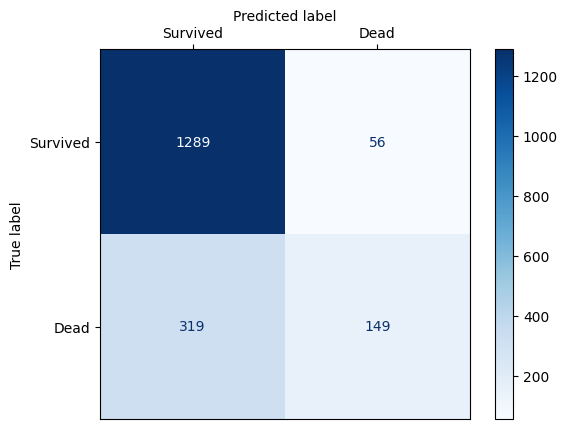

In [16]:
print("--- Classification Report  ---")
print(classification_report(y_test, y_pred, target_names=['Survived', 'Dead']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Survived', 'Dead'])
disp.plot(cmap=plt.cm.Blues)
disp.ax_.xaxis.tick_top()
disp.ax_.xaxis.set_label_position('top')


The classification report and underlying confusion matrix perfectly illustrate the strategic tradeoff made during the hyperparameter tuning phase. Out of the 1,813 total patients in the test set, the algorithm correctly identified the vast majority of survivors (approx. 1,289 True Negatives). Because we explicitly optimized the Random Forest for Precision to prioritize absolute diagnostic certainty, the model adopts a highly conservative approach before predicting a fatal outcome. This rigorous calibration successfully restricts False Positives (survivors incorrectly flagged as terminal) to just 56 cases, achieving a precision of 69% for the minority class. While this strict threshold inevitably lowers the recall resulting in 319 False Negatives (deceased patients not flagged in advance) this is precisely the desired behavior for futility prediction: ethically, it is far safer to miss a terminal prognosis than to falsely condemn a survivable patient by incorrectly recommending the withdrawal of care

To transition our predictive engine from a "black box" to an interpretable clinical tool, this code extracts the internal decision-making weights of our optimized Random Forest. First, we isolate the preprocessor and the classifier from the pipeline to retrieve the exact feature names and their corresponding Gini importance scores. After mapping these values into a structured DataFrame, we apply a string manipulation step to strip away scikit-learn's internal preprocessing prefixes (such as remainder__), ensuring clean, human-readable labels. Finally, we isolate the top 10 most influential clinical attributes and visualize them using an elegant, horizontal bar chart (plotnine). This provides immediate visual feedback on which vital signs and patient history metrics carry the highest "decisional weight" when the algorithm predicts mortality risk.

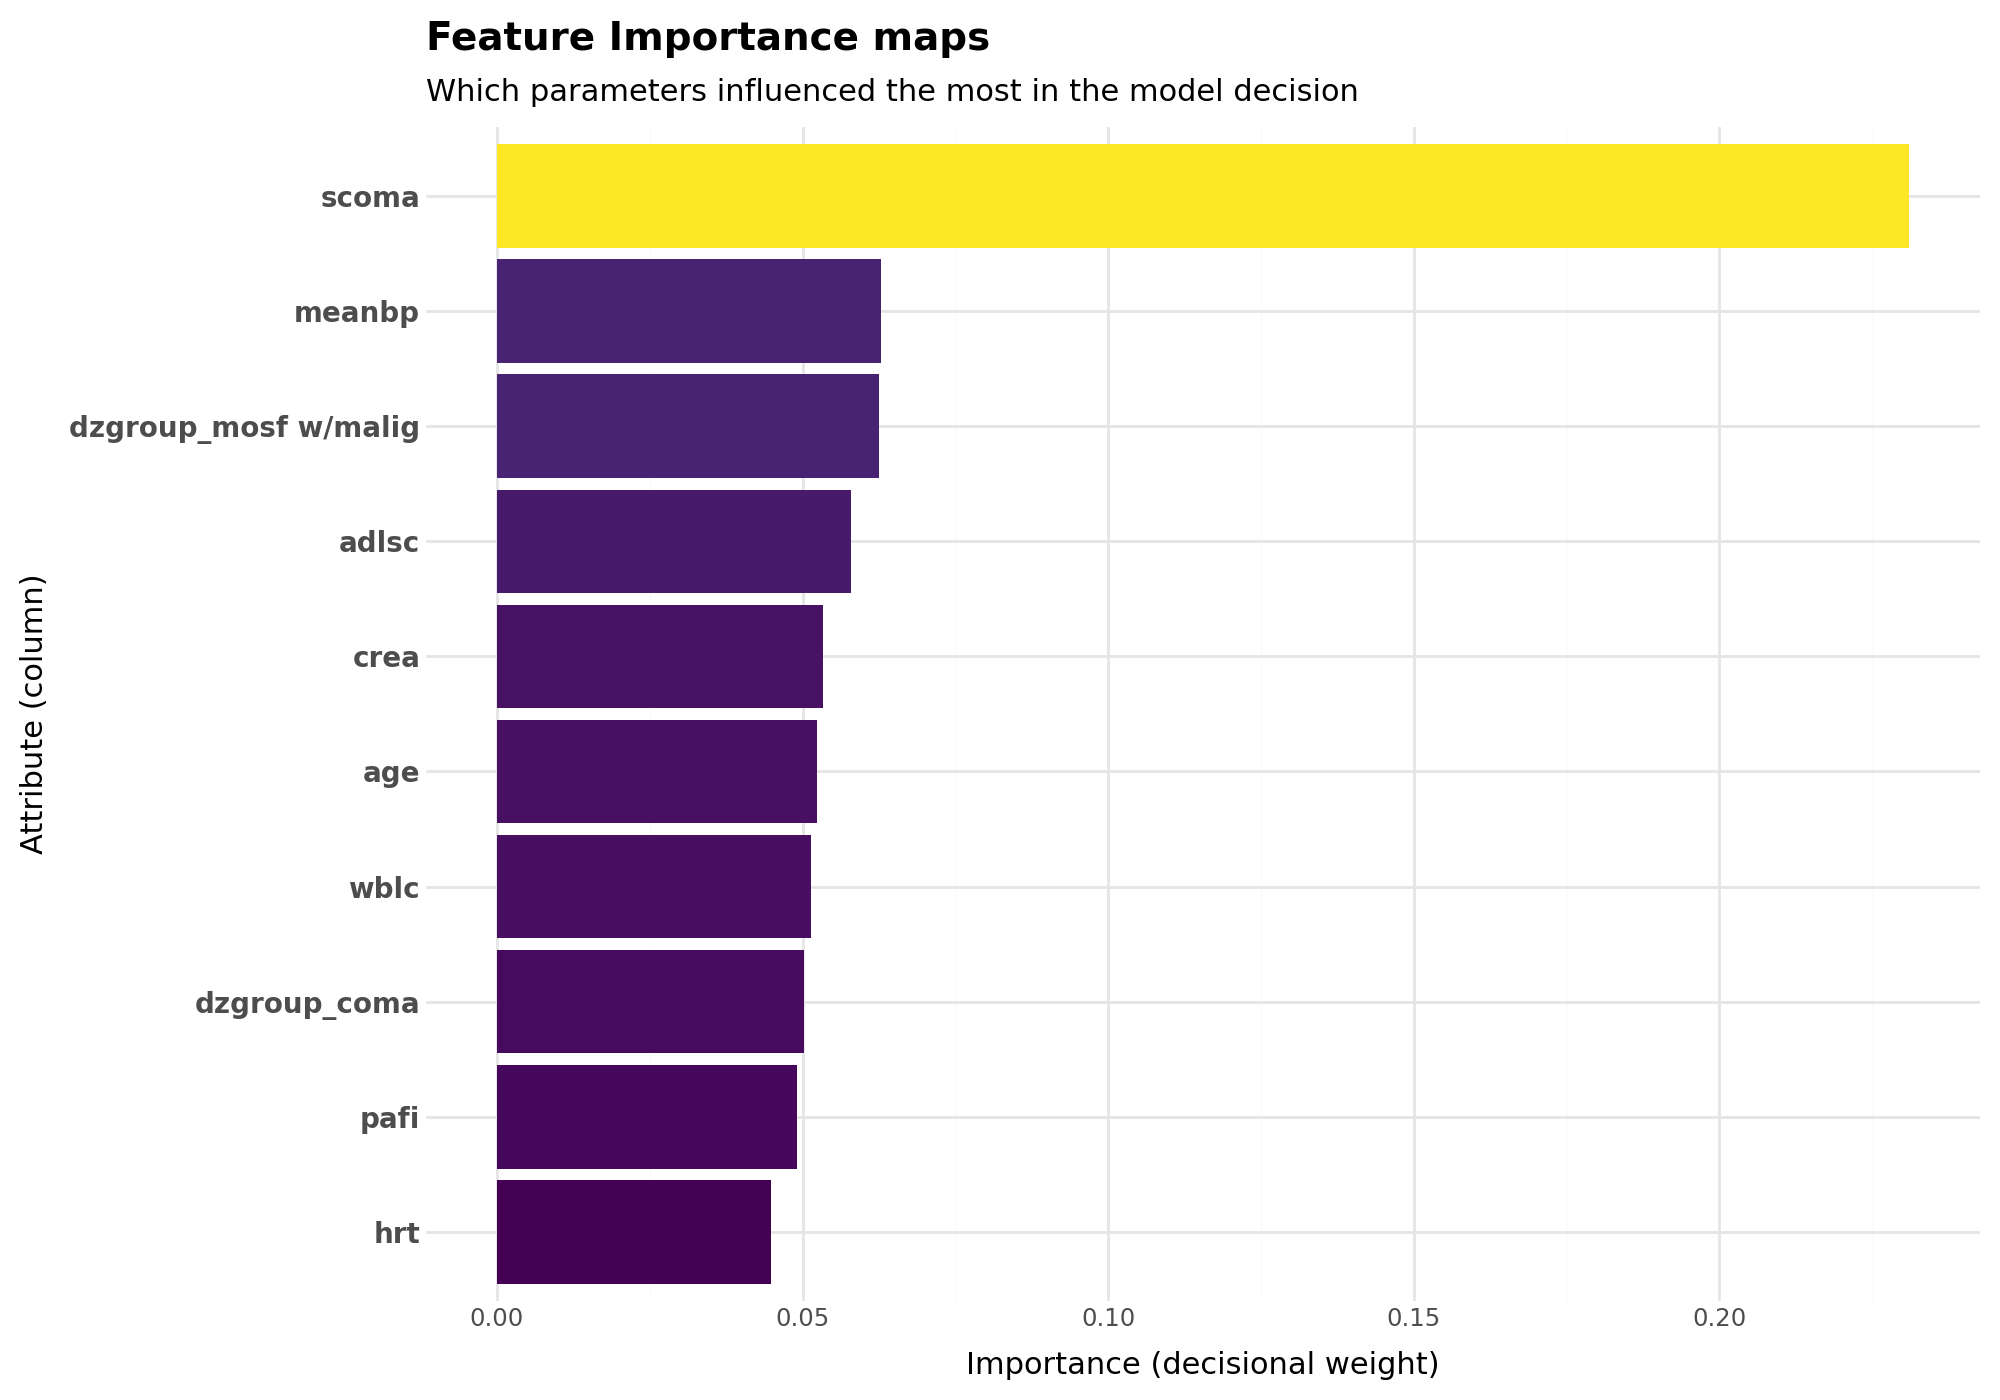

In [17]:
preprocessor = best_rf_model.named_steps['preprocessor']
rf_model = best_rf_model.named_steps['classifier']

nomi_feature = preprocessor.get_feature_names_out()

importanza = rf_model.feature_importances_

importanza_df = pd.DataFrame({
    'Feature': nomi_feature,
    'Importance': importanza
})
importanza_df['Feature'] = importanza_df['Feature'].str.split('__').str[-1]

top_10_features = importanza_df.sort_values(by='Importance', ascending=False).head(10)

categorie_ordinate = top_10_features.sort_values('Importance')['Feature'].tolist()
top_10_features['Feature'] = pd.Categorical(
    top_10_features['Feature'], 
    categories=categorie_ordinate, 
    ordered=True
)

grafico_importanza = (
    p9.ggplot(top_10_features, p9.aes(x='Feature', y='Importance', fill='Importance'))
    + p9.geom_col(show_legend=False)
    + p9.coord_flip() 
    + p9.scale_fill_cmap(cmap_name='viridis') 
    + p9.theme_minimal()
    + p9.labs(
        title="Feature Importance maps",
        subtitle="Which parameters influenced the most in the model decision",
        x="Attribute (column)",
        y="Importance (decisional weight)"
    )
    + p9.theme(
        axis_text_y=p9.element_text(size=10, weight='bold'),
        plot_title=p9.element_text(size=14, weight='bold'),
        figure_size=(10, 7)
    )
)

grafico_importanza

In this section, we peek inside the Random Forest to see exactly which variables it prioritized when predicting clinical outcomes.

We extract the feature names and their "importance scores" directly from the trained pipeline. After cleaning up the column names (removing the internal scikit-learn prefixes), we sort the data to find the Top 10 most critical features and plot them using plotnine.

Clinical Interpretation:
The feature importance plot reveals a highly logical medical hierarchy:

* **`Neurological Factor`:** The scoma feature stands out as the primary driver of the model's mortality predictions.

* **`The Power of One-Hot Encoding`:** Notice the presence of dzgroup_mosf w/malig in the top 10. By splitting the disease groups into independent binary columns earlier in our pipeline, we allowed the algorithm to recognize that this specific condition (Multiple Organ System Failure with Malignancy) is a massive, independent red flag for mortality.

* **`Vital Signs`:** The heavy presence of real-time metrics such as meanbp, age, crea, and pafi demonstrates that the algorithm heavily grounds its predictions in objective, acute physiological deterioration.

## In-depth Analysis of Hyperparameter Tuning 

In the preceding analysis, we intentionally optimized our Random Forest model for Precision to establish a conservative, ethically sound baseline one that strictly minimizes the risk of false positive mortality predictions. However, to fully understand the mathematical and clinical trade-offs of this decision, it is crucial to investigate how the algorithm's behavior shifts when the optimization objective is altered. In this section, we expand our hyperparameter search space and tune the model independently for Recall, F1-Score, Accuracy, and ROC-AUC. By mapping these alternative configurations, we aim to observe the direct consequences of prioritizing general sensitivity or global accuracy over absolute diagnostic certainty.


In [42]:
df = pd.read_csv('dataset_clean_tidy_filled.csv')
df = df.drop(columns=['dnr','aps','hday'])
r_cols = ['temp','meanbp','hrt','resp','sod','age']
p_cols = ['wblc','crea','pafi']
one_hot_cols = ['dzgroup','ca','race','sex','income']
preprocessor = ColumnTransformer(transformers=[
    ('robus_scaler',RobustScaler(),r_cols),
    ('power_transf',PowerTransformer(method='box-cox', standardize=True),p_cols),
    ('one_hot_enc', OneHotEncoder(handle_unknown='ignore',sparse_output=False,),one_hot_cols)
], remainder='passthrough')
y = df['hospdead']
X = df.drop(columns=['hospdead'])
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20, random_state=42, stratify=y)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,              
        random_state=42
    ))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = cross_validate(rf_pipeline, X_train, y_train, cv=cv, scoring=scoring_metrics)


### Recall

In [ ]:
param_dist_r = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 15, 20,30,40,50], ## Read below paragraph to understand this choice of expanded domain
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}
random_search_r = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_r,
    n_iter=20, 
    scoring='recall',  # <---- Changed from precision
    cv=cv, 
    random_state=42,
    n_jobs=-1
)
random_search_r.fit(X_train, y_train)
best_rf_model_r = random_search_r.best_estimator_

### F1

In [ ]:
param_dist_f1 = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 15, 20,30,40,50], ## Read below paragraph to understand this choice of expanded domain
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}
random_search_f1 = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_f1,
    n_iter=20, 
    scoring='f1',  # <---- Changed from precision
    cv=cv, 
    random_state=42,
    n_jobs=-1
)
random_search_f1.fit(X_train, y_train)
best_rf_model_f1 = random_search_f1.best_estimator_

### Accuracy

In [36]:
param_dist_a = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 15, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}
random_search_a = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_a,
    n_iter=20, 
    scoring='accuracy',  # <---- Changed from precision
    cv=cv, 
    random_state=42,
    n_jobs=-1
)
random_search_a.fit(X_train, y_train)
best_rf_model_a = random_search_a.best_estimator_

### ROC_AUC

In [ ]:
param_dist_ra = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 15, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}
random_search_ra = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_ra,
    n_iter=20, 
    scoring='roc_auc',  # <---- Changed from precision
    cv=cv, 
    random_state=42,
    n_jobs=-1
)
random_search_ra.fit(X_train, y_train)
best_rf_model_ra = random_search_ra.best_estimator_

Test

In [ ]:
y_pred_1 = best_rf_model_r.predict(X_test)
test_accuracy_r = accuracy_score(y_test, y_pred_1)
print(f"FINAL ACCURACY TEST Recall: {test_accuracy_r:.4f}\n")

y_pred_2 = best_rf_model_f1.predict(X_test)
test_accuracy_f1 = accuracy_score(y_test, y_pred_2)
print(f"FINAL ACCURACY TEST F1: {test_accuracy_f1:.4f}\n")

y_pred_3 = best_rf_model_a.predict(X_test)
test_accuracy_a = accuracy_score(y_test, y_pred_3)
print(f"FINAL ACCURACY TEST Accuracy: {test_accuracy_a:.4f}\n")

y_pred_4 = best_rf_model_ra.predict(X_test)
test_accuracy_ra = accuracy_score(y_test, y_pred_4)

# For ROC AUC we use predicted probabilities
y_proba_4 = best_rf_model_ra.predict_proba(X_test)[:, 1]
test_roc_auc = roc_auc_score(y_test, y_proba_4)
print(f"FINAL ROC AUC (probability-based): {test_roc_auc:.4f}\n")


FINAL ACCURACY TEST Recall: 0.7921

FINAL ACCURACY TEST F1: 0.7910

FINAL ACCURACY TEST Accuracy: 0.7871

FINAL ACCURACY TEST ROC_AUC (accuracy of model): 0.7926

FINAL ROC AUC (probability-based): 0.7938




### An Interesting result (F1 and Recall)

Initial evaluations yielded an overall accuracy of 0.7871(for accuracy) and a ROC-AUC(for roc_auc) score of 0.7938. Interestingly, optimizing the hyperparameter search for F1-score and optimizing for Recall produced identical performance metrics, resulting in the exact same confusion matrix. To investigate this unexpected convergence, we expanded the hyperparameter search space. Specifically, by introducing higher upper bounds to the max_depth parameter grid (e.g., 30, 40, and 50), the optimization strategies began to yield divergent models. We can therefore deduce that the previously identical results were an artifact of a restrictive hyperparameter grid, which artificially forced both scoring metrics to converge on the exact same estimator.

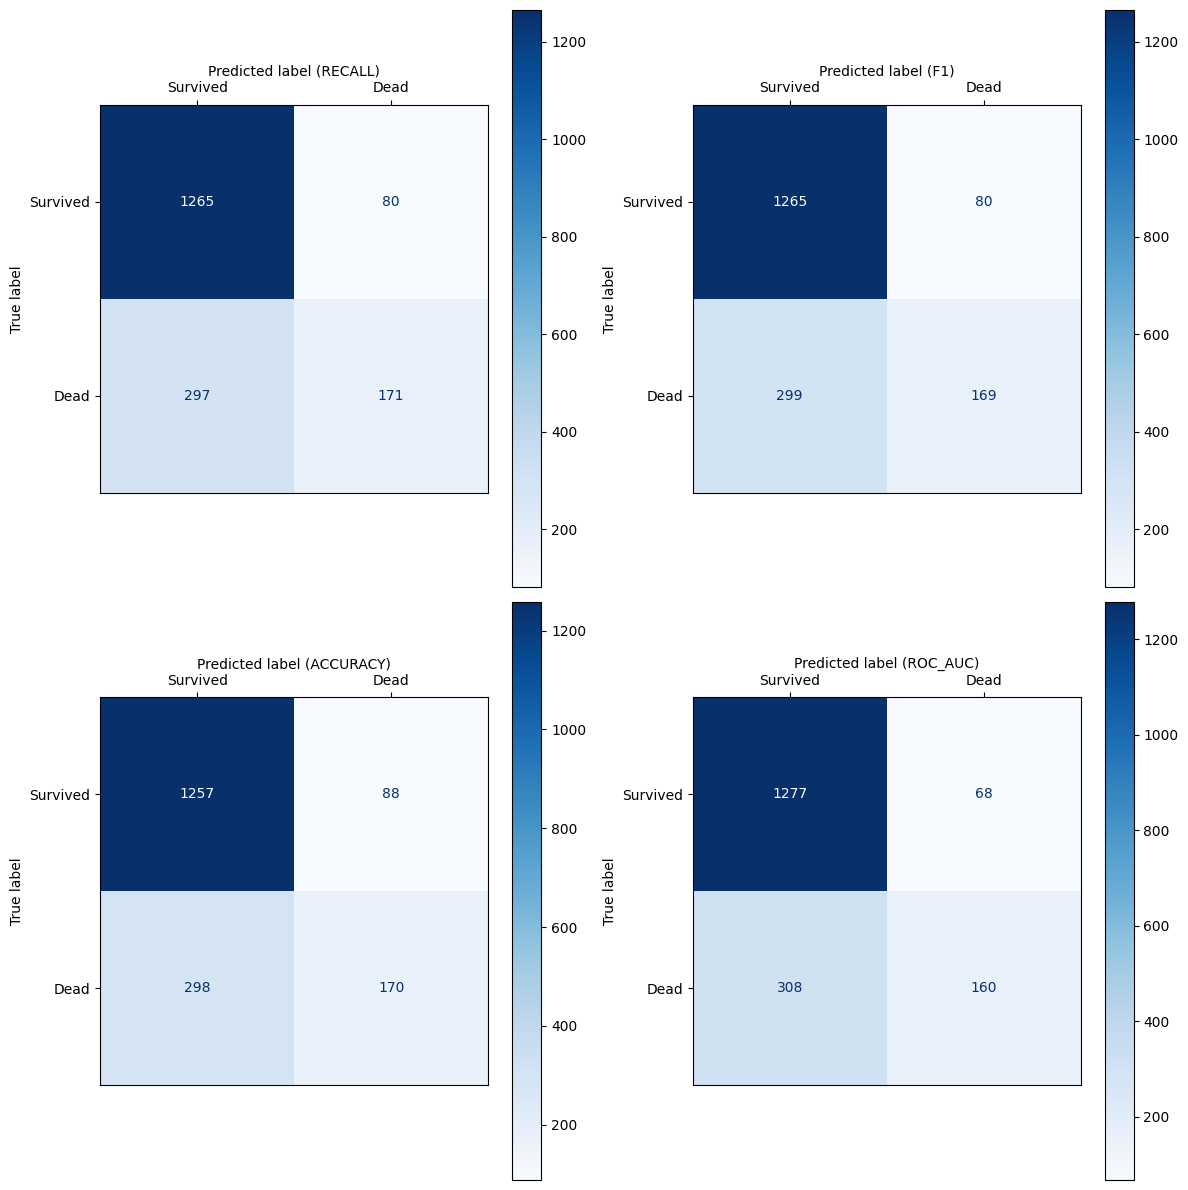

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

cm_1 = confusion_matrix(y_test, y_pred_1)
disp_1 = ConfusionMatrixDisplay(confusion_matrix=cm_1, display_labels=['Survived', 'Dead'])
disp_1.plot(cmap=plt.cm.Blues, ax=axes[0, 0])  
axes[0, 0].xaxis.tick_top()
axes[0, 0].xaxis.set_label_position('top')
axes[0, 0].set_xlabel('Predicted label (RECALL)')

cm_2 = confusion_matrix(y_test, y_pred_2)
disp_2 = ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=['Survived', 'Dead'])
disp_2.plot(cmap=plt.cm.Blues, ax=axes[0, 1])
axes[0, 1].xaxis.tick_top()
axes[0, 1].xaxis.set_label_position('top')
axes[0, 1].set_xlabel('Predicted label (F1)')


cm_3 = confusion_matrix(y_test, y_pred_3)
disp_3 = ConfusionMatrixDisplay(confusion_matrix=cm_3, display_labels=['Survived', 'Dead'])
disp_3.plot(cmap=plt.cm.Blues, ax=axes[1, 0])
axes[1, 0].xaxis.tick_top()
axes[1, 0].xaxis.set_label_position('top')
axes[1, 0].set_xlabel('Predicted label (ACCURACY)')



cm_4 = confusion_matrix(y_test, y_pred_4)
disp_4 = ConfusionMatrixDisplay(confusion_matrix=cm_4, display_labels=['Survived', 'Dead'])
disp_4.plot(cmap=plt.cm.Blues, ax=axes[1, 1])
axes[1, 1].xaxis.tick_top()
axes[1, 1].xaxis.set_label_position('top')
axes[1, 1].set_xlabel('Predicted label (ROC_AUC)')

plt.tight_layout()
plt.show()

### Comparative Analysis: Precision vs. Alternative Optimization Strategies

The inclusion of an expanded hyperparameter search space reveals distinct behavioral shifts in the Random Forest model depending on the scoring metric optimized. By comparing the four alternative strategies against our baseline Precision-tuned model, we can clearly observe the mathematical and ethical trade-offs between model sensitivity and diagnostic caution.

Diagnostic Shifts by Optimization Metric:

* Precision (The Baseline): As seen in the initial matrix, optimizing specifically for Precision yields the most conservative and protective estimator. It logs the absolute lowest number of False Positives (56) and the highest True Negatives (1,289). By demanding high statistical certainty before predicting mortality, it successfully intercepts 149 terminal cases while maximizing the protection of the majority class.

* Recall & F1-Score: Tuning for Recall or F1 forces the algorithm to aggressively hunt for the minority class. This successfully increases the True Positives to 171 and 169, respectively (identifying roughly 20 more terminal patients than Precision). However, this sensitivity comes at a steep cost: False Positives jump to 80.

* Accuracy: Optimizing purely for global accuracy in an imbalanced dataset proves to be the most clinically risky strategy. While it correctly identifies 170 terminal cases, it generates the highest number of False Positives (88) demonstrating exactly why pure accuracy fails to navigate the specific risks of the minority class.

* ROC-AUC: This configuration attempts to balance the True Positive and False Positive rates. It intercepts 160 terminal cases while allowing 68 False Positives, acting as a mathematical middle-ground between the strictness of Precision and the aggressiveness of Recall.


In the context of predicting in-hospital mortality, the cost of a False Positive (incorrectly predicting death for a patient who would otherwise survive) is ethically severe, as it could influence the premature withdrawal of life-sustaining treatments or DNR orders. Conversely, a False Negative (missing a terminal prognosis) merely results in the patient continuing to receive standard-of-care treatment. While optimizing for Recall or Accuracy identifies slightly more terminal patients, the accompanying surge in False Positives (jumping from 56 up to 88) makes them clinically dangerous. Therefore, the Precision-tuned model remains the safest and most ethically sound deployment strategy, prioritizing the protection of survivable patients above all else.

### How demographic parameters like Race and Sex impacted in the model prediction?

In this section, we analyze the extent to which demographic parameters, specifically race and sex, influenced the model's predictions.

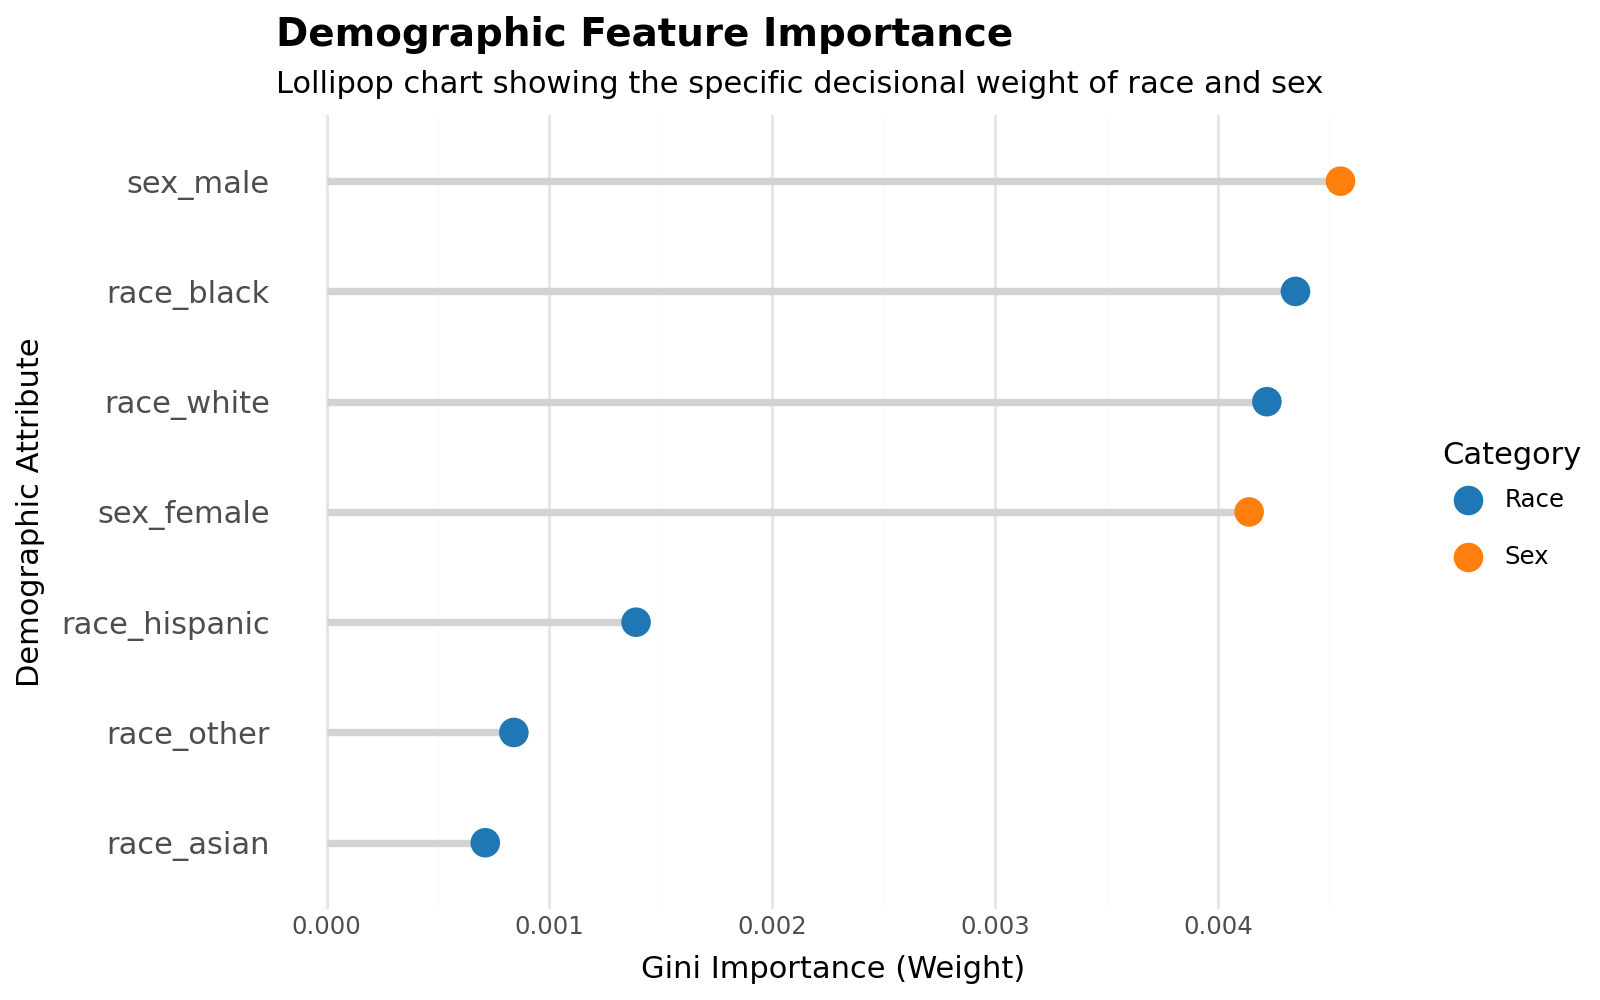

In [ ]:



preprocessor = best_rf_model.named_steps['preprocessor']
rf_model = best_rf_model.named_steps['classifier']
nomi_feature = preprocessor.get_feature_names_out()
importanza = rf_model.feature_importances_

importanza_df = pd.DataFrame({'Feature': nomi_feature, 'Importance': importanza})
importanza_df['Feature'] = importanza_df['Feature'].str.split('__').str[-1]

df_plot = importanza_df[importanza_df['Feature'].str.contains('race|sex', case=False)].copy()

df_plot['Macro_Category'] = 'Race'
df_plot.loc[df_plot['Feature'].str.contains('sex', case=False), 'Macro_Category'] = 'Sex'

categorie_ordinate = df_plot.sort_values('Importance')['Feature'].tolist()
df_plot['Feature'] = pd.Categorical(df_plot['Feature'], categories=categorie_ordinate, ordered=True)

grafico_lollipop = (
    p9.ggplot(df_plot, p9.aes(x='Feature', y='Importance', color='Macro_Category'))
  
    + p9.geom_segment(p9.aes(x='Feature', xend='Feature', y=0, yend='Importance'), size=1.5, color='#d3d3d3')

    + p9.geom_point(size=5)
    + p9.coord_flip() 
    + p9.scale_color_manual(values={'Race': '#1f77b4', 'Sex': '#ff7f0e'})
    + p9.theme_minimal()
    + p9.labs(
        title="Demographic Feature Importance",
        subtitle="Lollipop chart showing the specific decisional weight of race and sex",
        x="Demographic Attribute",
        y="Gini Importance (Weight)",
        color="Category"
    )
    + p9.theme(
        axis_text_y=p9.element_text(size=11),
        plot_title=p9.element_text(size=14, weight='bold'),
        panel_grid_major_y=p9.element_blank(), 
        figure_size=(8, 5)
    )
)

grafico_lollipop

The features are ranked in descending order of their contribution to the model's predictive splits.

Key Observations:

* Relative Ranking: Within this isolated demographic subset, sex_male, race_black, and race_white emerge as the relatively most "important" features, while race_asian and race_other have the least influence.

* Absolute Magnitude (The Clinical Takeaway): The most critical observation from this chart is the scale of the X-axis. The absolute maximum importance weight achieved by sex_male is roughly 0.0045. To put this in perspective, primary physiological predictors (such as coma scores or blood pressure) typically register Gini weights that are orders of magnitude higher.

This visualization provides definitive mathematical proof that the model's mortality predictions are driven almost entirely by objective clinical deterioration rather than the patient's baseline demographics. The algorithm assigns a near-zero, negligible predictive weight to a patient's race or sex.